# Benchmark quantum memory with circuit-level noise

A quantum-memory experiment asks whether encoded information survives repeated rounds of error correction.
It prepares an eigenstate of a chosen logical observable, repeatedly measures the code stabilizers, and finally reads out that observable.
Changes in otherwise predictable measurement outcomes become detector events, which a decoder uses to infer whether the logical value flipped.

Unlike the code-capacity model, a circuit-level benchmark can include faults in gates, resets, measurements, and idle moments.
The depolarizing model used below applies noise to active operations but disables idle noise explicitly.
The examples run one logical basis at a time: an X-basis experiment tracks X-type logical observables, while a Z-basis experiment tracks Z-type logical observables.
For a distance-$d$ code, using $d$ syndrome-measurement rounds gives the experiment distance $d$ in the time direction, matching its distance against data errors.


## Setup

Run the next cell once in a fresh notebook environment.
IPython's `%pip` magic installs into the active kernel, so the following imports use the same environment.


In [1]:
%%capture
%pip install qldpc matplotlib

In [2]:
import os
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
import sinter
from matplotlib.figure import Figure

from qldpc import circuits, codes, decoders
from qldpc.objects import Pauli, PauliXZ

NUM_WORKERS = max(1, min(4, (os.cpu_count() or 1) - 1))

## Build Sinter tasks

`run_memory_experiments` takes explicit `(code, num_rounds)` pairs, making the experiment's temporal extent a caller choice.
The examples use a round count equal to each code's known exact distance rather than silently substituting a randomized distance upper bound.


In [3]:
def code_label(code: codes.CSSCode) -> str:
    """Return a compact quantum-code parameter label for a plot legend."""
    known_distance = code.get_distance_if_known()
    suffix = f", {known_distance}" if known_distance is not None else ""
    return f"[[{len(code)}, {code.dimension}{suffix}]]"


def run_memory_experiments(
    codes_and_rounds: Sequence[tuple[codes.CSSCode, int]],
    basis: PauliXZ,
    decoder: sinter.Decoder,
    *,
    error_rates: Sequence[float] = tuple(np.logspace(-3, -2, 5)),
    max_shots: int = 20_000,
    max_errors: int = 100,
) -> list[sinter.TaskStats]:
    """Sample fixed-basis memory experiments over codes and physical error rates."""
    tasks = []
    for code, num_rounds in codes_and_rounds:
        assert num_rounds >= 1
        for probability in error_rates:
            noise = circuits.DepolarizingNoiseModel(
                probability,
                include_idling_error=False,
            )
            circuit = circuits.get_memory_experiment(
                code,
                basis=basis,
                num_rounds=num_rounds,
                noise_model=noise,
            )
            tasks.append(
                sinter.Task(
                    circuit=circuit,
                    json_metadata={
                        "label": code_label(code),
                        "probability": probability,
                    },
                )
            )

    return sinter.collect(
        tasks=tasks,
        decoders=["qldpc"],
        custom_decoders={"qldpc": decoder},
        num_workers=NUM_WORKERS,
        max_shots=max_shots,
        max_errors=max_errors,
        print_progress=False,
    )


def plot_fixed_basis_results(
    codes_and_rounds: Sequence[tuple[codes.CSSCode, int]],
    decoder: sinter.Decoder,
) -> tuple[Figure, npt.NDArray[np.object_]]:
    """Run and plot X- and Z-basis memory experiments."""
    figure, axes = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
    markers = ("o", "s", "^", "D")

    for axis, basis in zip(axes, (Pauli.X, Pauli.Z)):
        stats = run_memory_experiments(codes_and_rounds, basis, decoder)
        sinter.plot_error_rate(
            ax=axis,
            stats=stats,
            x_func=lambda stat: stat.json_metadata["probability"],
            group_func=lambda stat: stat.json_metadata["label"],
            plot_args_func=lambda index, _curve_id: {
                "marker": markers[index % len(markers)],
            },
        )
        reference_rates = sorted({stat.json_metadata["probability"] for stat in stats})
        axis.plot(
            reference_rates,
            reference_rates,
            color="black",
            linestyle=":",
            label=r"$p_{\mathrm{logical}}=p_{\mathrm{physical}}$",
        )
        axis.set_title(f"{basis.name}-basis memory")
        axis.set_xlabel("physical error rate per operation")
        axis.loglog()
        axis.grid(which="both", alpha=0.3)

    axes[0].set_ylabel("estimated logical error rate")
    axes[1].legend(loc="best")
    figure.tight_layout()
    return figure, axes

## Surface codes with MWPM

Each fixed-basis circuit uses one code block and exposes only the selected family of logical observables.
The surface-code detector error models are graphlike, so minimum-weight perfect matching (MWPM) can decode them directly.


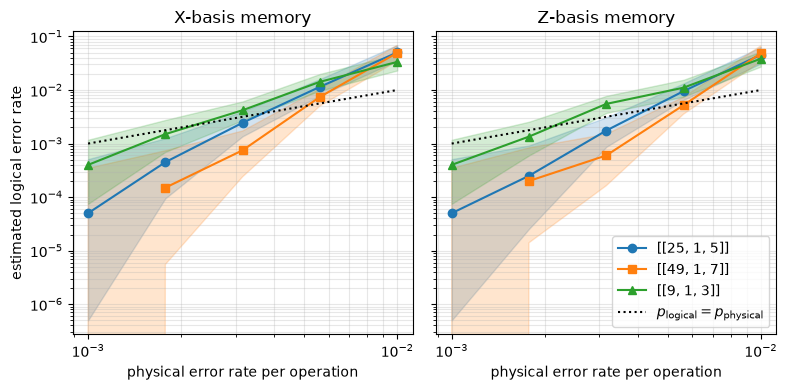

In [4]:
surface_codes = [(codes.SurfaceCode(distance, rotated=True), distance) for distance in (3, 5, 7)]
mwpm_decoder = decoders.ObservableDecoder(decoder=decoders.mwpm())

plot_fixed_basis_results(surface_codes, mwpm_decoder)
plt.show()

The X- and Z-basis panels need not agree exactly: their circuit geometries differ, and each estimate comes from a finite sample.


## Toric codes with BP+LSD

The same experiment and plotting functions can use a different decoder.
For these non-graphlike toric-code detector models, BP+LSD retains correlated mechanisms that MWPM cannot consume directly, at greater computational cost.


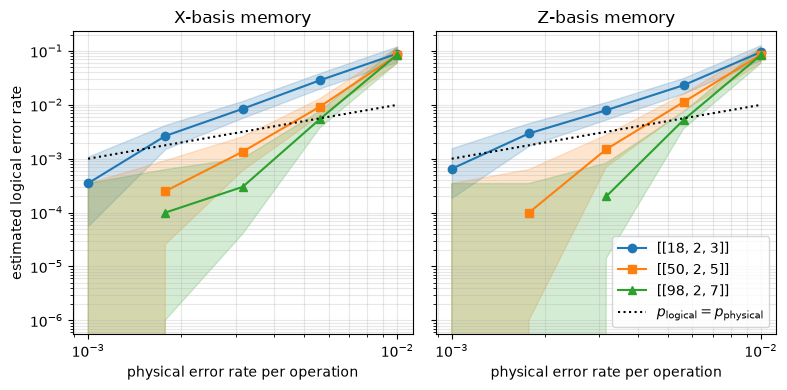

In [5]:
toric_codes = [(codes.ToricCode(distance, rotated=False), distance) for distance in (3, 5, 7)]
bp_lsd_decoder = decoders.ObservableDecoder(
    decoder=decoders.bp_lsd(
        max_iter=30,
        bp_method="ms",
        lsd_method="lsd_cs",
        lsd_order=0,
    )
)

plot_fixed_basis_results(toric_codes, bp_lsd_decoder)
plt.show()